# Advertising sales prediction using multiple linear regression

## Project overview

This project develops a multiple linear regression model to predict company sales based on advertising expenditures across TV, radio, and newspaper channels.

The analysis implements Ordinary Least Squares (OLS) using matrix operations and compares the results with the automated implementation provided by Statsmodels. Statistical inference and regression diagnostics are also performed to evaluate coefficient significance and the assumptions of the linear regression model.

## Import required libraries

In [116]:
import warnings 

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import math

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_white
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn import metrics

## Load the dataset

In [7]:
ads = pd.read_csv("Advertising.csv")
ads.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


### Dataset overview

In [25]:
ads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


## Define predictor and response variables

The predictor matrix includes advertising expenditures for TV, radio, and newspaper. A constant is added to estimate the intercept of the multiple linear regression model.

In [6]:
X_data = ads[['TV','Radio','Newspaper']].values
X_data = sm.add_constant(X_data) 
Y_data= ads[['Sales']].values

## Split the data into training and test sets

The dataset is divided into 70% training data and 30% test data. A fixed random state is used to ensure reproducibility.

In [24]:
X_train, X_test, y_train,y_test = train_test_split(X_data,Y_data, test_size = 0.3, random_state = 1)

In [25]:
X = X_train
Y = y_train

In [26]:
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (140, 4)
Y shape: (140, 1)


In [27]:
np.set_printoptions(formatter={'float_kind':'{:f}'.format})

## Manual estimation of OLS coefficients

The Ordinary Least Squares coefficients are estimated manually using the matrix equation:

$$
\hat{\beta} = (X^T X)^{-1}X^T Y
$$

This calculation provides the intercept and coefficients for TV, radio, and newspaper advertising expenditures.

In [28]:
XT_X = np.matmul(np.matrix.transpose(X),X)
XT_X

array([[140.000000, 19980.600000, 3248.700000, 4204.600000],
       [19980.600000, 3901273.080000, 470424.050000, 617291.510000],
       [3248.700000, 470424.050000, 107757.590000, 116260.540000],
       [4204.600000, 617291.510000, 116260.540000, 191020.340000]])

In [29]:
XT_X_inv = np.linalg.inv(XT_X)
XT_X_inv

array([[0.046027, -0.000128, -0.000530, -0.000277],
       [-0.000128, 0.000001, -0.000000, -0.000000],
       [-0.000530, -0.000000, 0.000037, -0.000011],
       [-0.000277, -0.000000, -0.000011, 0.000019]])

In [30]:
XT_Y = np.matmul(np.matrix.transpose(X),Y)
XT_Y

array([[2078.700000],
       [355094.550000],
       [51899.210000],
       [65195.270000]])

In [20]:
betas = np.matmul(XT_X_inv,XT_Y)
betas

array([[4.661440],
       [0.055024],
       [0.102510],
       [-0.001507]])

## Model goodness of fit

The goodness of fit is evaluated using the Total Sum of Squares (TSS), Explained Sum of Squares (ESS), and Residual Sum of Squares (RSS). These components are then used to calculate \(R^2\) and adjusted \(R^2\).

In [32]:
TSS = (np.matmul(np.matrix.transpose(Y),Y)- len(Y)* (Y.mean()**2)).item()
TSS

3987.349357142848

In [33]:
ESS = (np.matmul(np.matmul(np.matrix.transpose(betas),np.matrix.transpose(X)),np.matmul(X,betas))-len(Y)*(Y.mean()**2)).item()
ESS

3586.1206693926797

In [35]:
RSS = (TSS-ESS)
RSS

401.2286877501683

In [37]:
R2 = (1 - RSS/TSS)
R2

0.8993745840124552

The \(R^2\) value represents the proportion of variation in sales explained by the advertising variables included in the model.

In [38]:
R2aj = (1 - (RSS/(X.shape[0]-X.shape[1]))/(TSS/ (X.shape[0]-1)))
R2aj

0.8971549057186123

## Model evaluation on the test set

The coefficients estimated from the training data are used to generate predictions for the test set. Model performance is then evaluated using out-of-sample \(R^2\).

In [40]:
y_pred = np.matmul(X_test,betas)
y_pred

array([[21.288161],
       [18.042132],
       [10.059590],
       [21.082241],
       [20.764760],
       [24.471874],
       [16.806436],
       [15.628857],
       [10.124799],
       [18.846019],
       [15.783897],
       [10.542970],
       [18.929287],
       [15.525580],
       [17.841271],
       [15.241203],
       [13.742128],
       [21.064373],
       [10.053927],
       [19.265009],
       [11.164512],
       [11.972118],
       [8.611790],
       [11.989721],
       [12.599140],
       [16.844795],
       [9.717089],
       [21.094899],
       [18.139425],
       [19.550087],
       [22.087962],
       [17.785280],
       [16.538835],
       [14.773039],
       [21.394589],
       [16.954916],
       [17.227550],
       [12.318669],
       [21.049822],
       [7.774739],
       [5.384675],
       [9.631390],
       [6.895492],
       [19.195074],
       [7.881252],
       [15.187667],
       [13.709784],
       [21.023294],
       [20.535006],
       [20.488675],
       

In [41]:
resid = y_test-y_pred
resid

array([[2.511839],
       [-1.442132],
       [1.840410],
       [-1.282241],
       [-3.164760],
       [1.028126],
       [0.093564],
       [2.271143],
       [0.375201],
       [-1.746019],
       [1.716103],
       [0.757030],
       [-1.529287],
       [1.174420],
       [0.558729],
       [0.658797],
       [-0.842128],
       [-3.264373],
       [-0.553927],
       [-0.865009],
       [-0.464512],
       [0.527882],
       [-0.111790],
       [-0.489721],
       [-0.699140],
       [3.055205],
       [0.382911],
       [-2.194899],
       [1.460575],
       [1.349913],
       [1.112038],
       [-0.885280],
       [0.761165],
       [1.926961],
       [-1.194589],
       [3.545084],
       [-0.727550],
       [-1.318669],
       [1.250178],
       [-0.174739],
       [-0.084675],
       [2.368610],
       [-0.195492],
       [-0.195074],
       [-2.381252],
       [-0.587667],
       [0.890216],
       [0.476706],
       [2.064994],
       [-0.788675],
       [0.539121],
      

In [43]:
print('Coeficiente R2', r2_score(y_test,y_pred))

Coeficiente R2 0.9071151423684274


## Estimation of regression error variance

The variance of the regression error is estimated using the residual sum of squares (RSS) divided by the residual degrees of freedom:

$$
s^2 = \frac{RSS}{n-p}
$$

where \(n\) is the number of observations and \(p\) is the number of estimated regression parameters, including the intercept.

In [45]:
s2 = RSS/(len(Y)-X.shape[1])
s2

2.950210939339473

### Standard error of the regression

The standard error of the regression is obtained as the square root of the estimated error variance:

$$
s = \sqrt{s^2}
$$

This value expresses the typical magnitude of the regression error in the same units as the response variable.

In [48]:
s = math.sqrt(s2)
s

1.7176178094499

## Statistical significance of regression coefficients

To evaluate whether each regression coefficient is statistically different from zero, a t-statistic is calculated for each coefficient and compared with the critical value from the Student's t-distribution.

The hypotheses for each coefficient are:

$$
H_0: \beta_i = 0
$$

$$
H_1: \beta_i \neq 0
$$

A significance level of 5% is used.

In [50]:
t_statistics = []

for i in range(X.shape[1]):
    t = betas[i].item() / (s * math.sqrt(XT_X_inv[i, i]))
    t_statistics.append(t)

t_statistics

[12.649902262107204, 32.74742685165091, 9.801487239127846, -0.2034850064010117]

In [51]:
degrees_freedom = len(Y) - X.shape[1]

t_critical = abs(stats.t.ppf(q=0.025, df=degrees_freedom))
t_critical

np.float64(1.9775607765589356)

In [52]:
coefficient_names = ['Intercept', 'TV', 'Radio', 'Newspaper']

for name, t in zip(coefficient_names, t_statistics):
    if abs(t) > t_critical:
        print(f"{name}: statistically significant")
    else:
        print(f"{name}: not statistically significant")

Intercept: statistically significant
TV: statistically significant
Radio: statistically significant
Newspaper: not statistically significant


### P-values for regression coefficients

The p-value provides an additional criterion for evaluating the statistical significance of each regression coefficient. At a significance level of 5%, a coefficient is considered statistically significant when its p-value is less than 0.05.

In [54]:
p_values = []

for t in t_statistics:
    p_value = stats.t.sf(abs(t), df=degrees_freedom) * 2
    p_values.append(p_value)

for name, p_value in zip(coefficient_names, p_values):
    print(f"{name}: p-value = {p_value:.3e}")

Intercept: p-value = 9.911e-25
TV: p-value = 2.241e-66
Radio: p-value = 1.739e-17
Newspaper: p-value = 8.391e-01


### Confidence intervals for regression coefficients

A 95% confidence interval is calculated for each regression coefficient.

If the confidence interval includes zero, the coefficient is not considered statistically significant at the 5% significance level.

In [55]:
confidence_intervals = []

for i in range(X.shape[1]):
    standard_error = s * math.sqrt(XT_X_inv[i, i])
    
    lower_bound = betas[i].item() - t_critical * standard_error
    upper_bound = betas[i].item() + t_critical * standard_error
    
    confidence_intervals.append((lower_bound, upper_bound))

for name, (lower, upper) in zip(coefficient_names, confidence_intervals):
    print(f"{name}: [{lower:.4f}, {upper:.4f}]")

Intercept: [3.9327, 5.3902]
TV: [0.0517, 0.0583]
Radio: [0.0818, 0.1232]
Newspaper: [-0.0162, 0.0131]


## Validation with Statsmodels

The manual OLS calculations are validated using the Statsmodels implementation. The automated regression summary allows the estimated coefficients, t-statistics, p-values, confidence intervals, and goodness-of-fit measures to be compared with the results obtained manually.

In [56]:
regressor = sm.OLS(Y,X).fit()
regressor.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     405.2
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           1.36e-67
Time:                        20:01:56   Log-Likelihood:                -272.35
No. Observations:                 140   AIC:                             552.7
Df Residuals:                     136   BIC:                             564.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6614      0.368     12.650      0.000       3.933       5.390
x1             0.0550      0.002     32.747      0.000       0.052       0.058
x2             0.1025      0.010      9.801      0.000       0.082       0.123
x3            -0.0015      0.007     -0.203      0.839      -0.016       0.013
==============================================================================
Omnibus:                       15.370   Durbin-Watson:                   2.041
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.876
Skew:                          -0.526   Prob(JB):                     2.41e-06
Kurtosis:                       4.824   Cond. No.                         432.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Backward feature selection

Backward selection is applied to the training data to identify a more parsimonious regression model.
The procedure begins with all predictor variables and iteratively removes the predictor with the highest p-value when that value exceeds the significance threshold of 0.05. The intercept is retained throughout the process.

In [89]:
X_base = pd.DataFrame(X_train,columns=['const', 'TV', 'Radio', 'Newspaper'])
y = y_train.squeeze().copy()

X_work = X_base.copy()
included = list(X_work.columns)

alpha = 0.05

while True:
    model = sm.OLS(y, X_work[included]).fit()
    
    p_values_backward = model.pvalues.drop('const')
    
    if p_values_backward.empty:
        break
    
    worst_feature = p_values_backward.idxmax()
    worst_p_value = p_values_backward.loc[worst_feature]
    
    if worst_p_value > alpha:
        print(
            f"Remove {worst_feature} "
            f"with p-value {worst_p_value:.4f}"
        )
        included.remove(worst_feature)
    else:
        break

print("\nFinal variables:")
print(included)

Remove Newspaper with p-value 0.8391

Final variables:
['const', 'TV', 'Radio']


## Prediction with the final regression model

After backward selection, the final model retains TV and radio as statistically significant predictors of sales.

The reduced model is used to estimate expected sales for a specific advertising scenario and to construct a 90% confidence interval for the mean response.

In [90]:
X_final = X_work[included]
final_model = sm.OLS(y, X_final).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     612.0
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           4.95e-69
Time:                        21:40:36   Log-Likelihood:                -272.37
No. Observations:                 140   AIC:                             550.7
Df Residuals:                     137   BIC:                             559.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6390      0.350     13.240      0.000       3.946       5.332
TV             0.0550      0.002     32.903      0.000       0.052       0.058
Radio          0.1016      0.010     10.677      0.000       0.083       0.120
==============================================================================
Omnibus:                       14.841   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               24.663
Skew:                          -0.512   Prob(JB):                     4.41e-06
Kurtosis:                       4.783   Cond. No.                         407.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Prediction scenario

The final model is used to estimate sales when TV advertising expenditure is 100 and radio advertising expenditure is 50.

In [91]:
new_data = pd.DataFrame({'const': [1],'TV': [100],'Radio': [50]})
new_data

,const,TV,Radio
0,1,100,50


### Manual confidence interval calculation
The 90% confidence interval for the mean response is calculated manually using matrix operations and the reduced regression model.
For the advertising scenario defined above, the margin of error is calculated from the estimated regression error, the critical t value, and the uncertainty associated with the predictor values.

In [99]:
X_final_array = X_final.values
XT_X_inv_final = np.linalg.inv(X_final_array.T @ X_final_array)

RSS_final = np.sum(final_model.resid ** 2)
degrees_freedom_final = len(y) - X_final.shape[1]

s2_final = RSS_final / degrees_freedom_final
s_final = math.sqrt(s2_final)

t_critical_final = abs(
    stats.t.ppf(q=0.05, df=degrees_freedom_final)
)

f = new_data.values
print("X'X inverse shape:", XT_X_inv_final.shape)
print("Prediction vector shape:", f.shape)
print("Regression standard error:", s_final)
print("Critical t-value:", t_critical_final)

X'X inverse shape: (3, 3)
Prediction vector shape: (1, 3)
Regression standard error: 1.7115981446906272
Critical t-value: 1.6560520804964847


In [100]:
margin_error = (
    t_critical_final
    * s_final
    * math.sqrt((f @ XT_X_inv_final @ f.T).item())
)

print("Margin of error:", margin_error)

Margin of error: 0.5034711983440172


In [101]:
y_hat = final_model.predict(new_data).iloc[0]

lower_bound = y_hat - margin_error
upper_bound = y_hat + margin_error

print(f"Predicted sales: {y_hat:.3f}")
print(f"90% confidence interval for mean sales: [{lower_bound:.3f}, {upper_bound:.3f}]")

Predicted sales: 15.222
90% confidence interval for mean sales: [14.718, 15.725]


## Regression diagnostics

The assumptions of the final regression model are evaluated using residual diagnostic plots. The residuals versus fitted values plot is used to visually assess linearity and homoscedasticity.

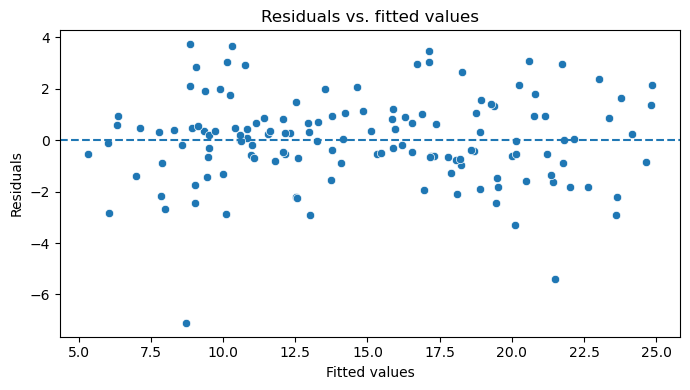

In [102]:
fitted = final_model.fittedvalues
residuals = final_model.resid

plt.figure(figsize=(7, 4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs. fitted values')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

### Normality of residuals

Residual normality is evaluated using skewness, excess kurtosis, the Jarque–Bera test, and a Q-Q plot.

For the Jarque–Bera test, the null hypothesis states that the residuals follow a normal distribution. A p-value below 0.05 provides evidence against normality.

Jarque-Bera p-value: 4.411e-06
Skewness: -0.518
Excess kurtosis: 1.892


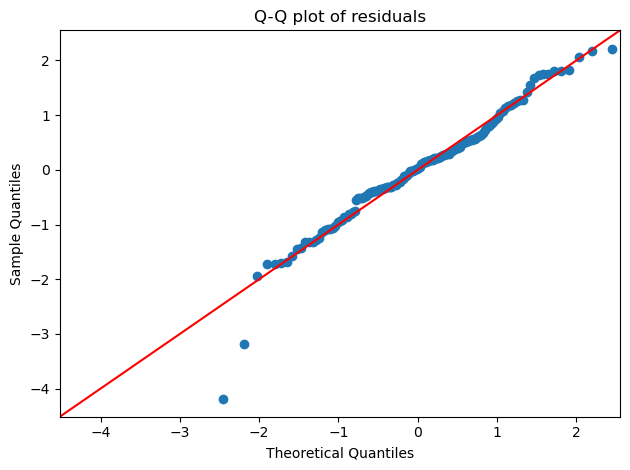

In [103]:
skew_value = stats.skew(residuals, bias=False)
kurt_value = stats.kurtosis(residuals, fisher=True, bias=False)
jb_stat, jb_pvalue = stats.jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_pvalue:.3e}")
print(f"Skewness: {skew_value:.3f}")
print(f"Excess kurtosis: {kurt_value:.3f}")

sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

### Normality assessment

The Jarque–Bera test produces a p-value well below 0.05, providing evidence against the null hypothesis of normally distributed residuals.

The Q-Q plot shows that most residuals approximately follow the theoretical normal distribution in the central region, but deviations are present in the tails. The negative skewness and positive excess kurtosis also indicate departures from normality.

Therefore, the normality assumption is not fully satisfied and inferential results should be interpreted with caution.

### Manual verification of skewness and kurtosis

To verify the results obtained with SciPy, skewness and excess kurtosis are calculated manually from the residuals using their statistical formulas. The manual results are then compared with the library results.

In [104]:
# Manual calculation of skewness
n = len(residuals)
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals, ddof=1)

sum_cubed = np.sum(((residuals - mean_residuals) / std_residuals) ** 3)

skew_manual = (n / ((n - 1) * (n - 2))) * sum_cubed

print(f"Manual skewness: {skew_manual:.3f}")
print(f"SciPy skewness:  {skew_value:.3f}")

Manual skewness: -0.518
SciPy skewness:  -0.518


In [106]:
# Manual calculation of excess kurtosis

n = len(residuals)
mean_residuals = np.mean(residuals)
std_residuals = np.std(residuals, ddof=1)

sum_fourth = np.sum(((residuals - mean_residuals) / std_residuals) ** 4)

kurt_manual = ((n * (n + 1) / ((n - 1) * (n - 2) * (n - 3))) * sum_fourth - (3 * (n - 1) ** 2 / ((n - 2) * (n - 3))))

print(f"Manual excess kurtosis: {kurt_manual:.3f}")
print(f"SciPy excess kurtosis:  {kurt_value:.3f}")

Manual excess kurtosis: 1.892
SciPy excess kurtosis:  1.892


### Independence of residuals

Residual independence is assessed using the Durbin–Watson statistic. Values close to 2 are consistent with the absence of substantial first-order autocorrelation.

In [107]:
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.3f}")

Durbin-Watson statistic: 2.038


The Durbin–Watson statistic is approximately 2.04, which is relatively close to 2 and does not indicate substantial first-order autocorrelation in the residuals.

### Manual verification of Durbin–Watson statistic

The Durbin–Watson statistic is calculated manually from the regression residuals and compared with the result obtained using Statsmodels.

In [108]:
# Manual calculation of Durbin-Watson statistic

residual_differences = np.diff(residuals)

numerator = np.sum(residual_differences ** 2)
denominator = np.sum(residuals ** 2)

dw_manual = numerator / denominator

print(f"Manual Durbin-Watson:     {dw_manual:.3f}")
print(f"Statsmodels Durbin-Watson: {dw:.3f}")

Manual Durbin-Watson:     2.038
Statsmodels Durbin-Watson: 2.038


### Multicollinearity

Multicollinearity among the predictors of the final model is assessed using the Variance Inflation Factor (VIF).

Higher VIF values indicate that a predictor can be substantially explained by the other predictors in the model. Values above 5 may indicate potentially problematic multicollinearity, while values above 10 are commonly considered evidence of severe multicollinearity.

In [109]:
#Multicolinealidad con el variance inflation factor
X_vif = X_final.drop(columns='const')

vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],index=X_vif.columns,name='VIF')
vif.to_frame()

,VIF
TV,2.111535
Radio,2.111535


Both TV and radio have VIF values of approximately 2.11, indicating that multicollinearity is not a major concern in the final regression model.

### Homoscedasticity

The White test is used to evaluate whether the variance of the regression residuals remains constant across observations.

The null hypothesis assumes homoscedasticity. A p-value below 0.05 provides evidence of heteroscedasticity.

In [110]:
white_test = het_white(residuals, X_final)
labels = ['LM statistic', 'LM p-value', 'F-statistic', 'F p-value']
white_results = dict(zip(labels, white_test))
for name, value in white_results.items():
    print(f"{name}: {value:.4f}")

LM statistic: 11.3534
LM p-value: 0.0448
F-statistic: 2.3652
F p-value: 0.0430


### Homoscedasticity assessment

Both p-values from the White test are below 0.05, providing evidence against the null hypothesis of constant error variance.

Therefore, the homoscedasticity assumption is not fully satisfied, suggesting that the variability of the residuals changes across observations. This result should be considered when interpreting conventional standard errors, hypothesis tests, and confidence intervals.

### Manual verification of the White test

The White test is reproduced manually by constructing an auxiliary regression in which the squared residuals are regressed on the original predictors, their squared terms, and their cross-product.

The LM statistic is then calculated from the R-squared of the auxiliary regression and compared with the result obtained using Statsmodels.

In [111]:
# Build the auxiliary matrix for the White test

tv = X_final['TV'].values
radio = X_final['Radio'].values

Z = np.column_stack([np.ones(len(tv)),tv,radio,tv ** 2,radio ** 2,tv * radio])

squared_residuals = residuals ** 2

print("Auxiliary matrix shape:", Z.shape)

Auxiliary matrix shape: (140, 6)


In [112]:
# Manual OLS estimation for the White auxiliary regression

ZTZ_inv = np.linalg.inv(Z.T @ Z)
beta_white = ZTZ_inv @ Z.T @ squared_residuals

fitted_white = Z @ beta_white
TSS_white = np.sum((squared_residuals - np.mean(squared_residuals)) ** 2)

RSS_white = np.sum((squared_residuals - fitted_white) ** 2)

R2_white = 1 - RSS_white / TSS_white

R2_white

np.float64(0.08109555822595582)

In [113]:
# Manual White LM statistic

n_white = len(residuals)

LM_white_manual = n_white * R2_white

# Number of restrictions in the auxiliary regression
df_white = Z.shape[1] - 1

p_value_white_manual = stats.chi2.sf(LM_white_manual,df_white)

print(f"Manual LM statistic: {LM_white_manual:.4f}")
print(f"Manual LM p-value:   {p_value_white_manual:.4f}")

print(f"\nStatsmodels LM statistic: {white_test[0]:.4f}")
print(f"Statsmodels LM p-value:   {white_test[1]:.4f}")

Manual LM statistic: 11.3534
Manual LM p-value:   0.0448

Statsmodels LM statistic: 11.3534
Statsmodels LM p-value:   0.0448


### Manual verification results

The manually calculated skewness, excess kurtosis, Durbin–Watson statistic, and White test results closely match those obtained with SciPy and Statsmodels.

This confirms that the library implementations are consistent with the statistical formulas applied manually to the residuals of the regression model.

## Model performance visualization

The following plot compares the observed sales values with the predictions generated by the regression model on the test data. Predictions closer to the diagonal reference line indicate better agreement between observed and predicted sales.

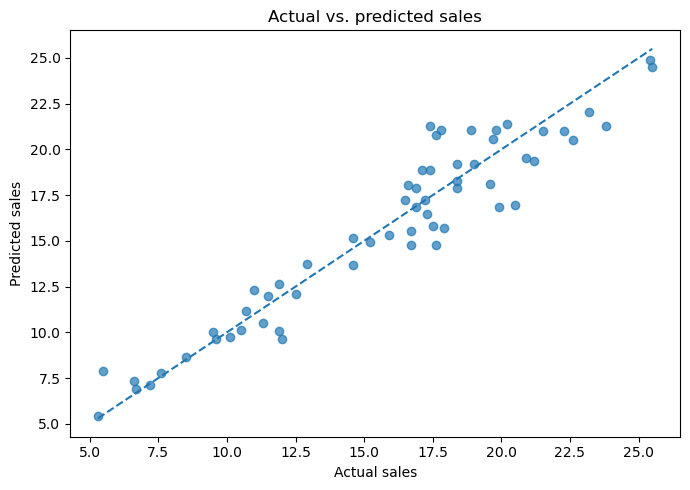

In [114]:
# Prepare test data for the final reduced model

X_test_final = pd.DataFrame(X_test,columns=['const', 'TV', 'Radio', 'Newspaper'])[['const', 'TV', 'Radio']]

y_test_values = y_test.squeeze()

# Generate predictions
y_test_pred = final_model.predict(X_test_final)

# Plot actual vs. predicted sales
plt.figure(figsize=(7, 5))

plt.scatter(y_test_values, y_test_pred, alpha=0.7)

min_value = min(y_test_values.min(), y_test_pred.min())
max_value = max(y_test_values.max(), y_test_pred.max())

plt.plot([min_value, max_value],[min_value, max_value],linestyle='--')

plt.xlabel('Actual sales')
plt.ylabel('Predicted sales')
plt.title('Actual vs. predicted sales')
plt.tight_layout()

plt.savefig('actual_vs_predicted_sales.png',dpi=300,bbox_inches='tight')
plt.show()

In [117]:
r2_final_test = r2_score(y_test_values, y_test_pred)
mae_final_test = mean_absolute_error(y_test_values, y_test_pred)
rmse_final_test = np.sqrt(
    mean_squared_error(y_test_values, y_test_pred)
)

print(f"Test R²: {r2_final_test:.3f}")
print(f"Test MAE: {mae_final_test:.3f}")
print(f"Test RMSE: {rmse_final_test:.3f}")

Test R²: 0.907
Test MAE: 1.192
Test RMSE: 1.538


The final reduced model achieved an out-of-sample R-squared of approximately 0.907 on the test set, with an MAE of 1.192 and an RMSE of 1.538. This indicates strong predictive performance on unseen observations despite removing Newspaper from the final model.

## Conclusions

The multiple linear regression analysis showed that TV and radio advertising expenditures are statistically significant predictors of sales, while newspaper advertising was not statistically significant and was removed during backward feature selection.

The final reduced model achieved an out-of-sample R-squared of approximately 0.907 on the test set, with an MAE of 1.192 and an RMSE of 1.538. This indicates strong predictive performance on unseen observations despite removing Newspaper from the final model.

For an advertising scenario with TV expenditure of 100 and radio expenditure of 50, the final model predicts sales of approximately 15.22, with a 90% confidence interval for the mean response of approximately [14.72, 15.73]. Newspaper expenditure does not enter this prediction because it was excluded from the final model.

Regression diagnostics indicate no substantial first-order autocorrelation and no major multicollinearity between the retained predictors. However, the Jarque–Bera and White tests provide evidence of departures from normality and homoscedasticity, respectively. Therefore, conventional inferential results should be interpreted with some caution.

Finally, manual calculations of skewness, excess kurtosis, the Durbin–Watson statistic, and the White test closely reproduced the results obtained with SciPy and Statsmodels, validating the statistical implementations used in the analysis.